In [1]:
import os
print(os.getcwd())


c:\Users\Legion\Desktop\Cripto


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import streamlit as st

In [3]:

df = pd.read_csv(r'C:\Users\Legion\Desktop\Cripto\merged_crypto_data.csv')

In [4]:
df.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,VWAP,TWAP,coin
0,1,2018-03-31,6877.060559,7224.073096,6845.765407,6980.794485,382634.619071,7044.705186,7044.127805,bitcoin
1,2,2018-03-30,7145.558812,7300.913155,6667.086968,6883.725208,609854.553605,6935.257228,6936.282983,bitcoin
2,3,2018-03-29,7983.837144,7996.389607,7005.998073,7154.143491,531839.173256,7535.636043,7574.005265,bitcoin
3,4,2018-03-28,7846.584324,8119.134881,7804.215096,7972.350959,275193.597624,7956.314335,7959.131977,bitcoin
4,5,2018-03-27,8189.532364,8244.970320,7806.926140,7856.948846,357522.246911,8007.858721,8009.491882,bitcoin


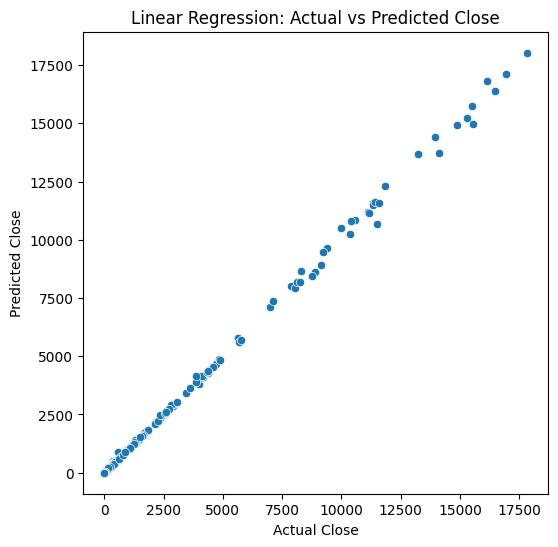

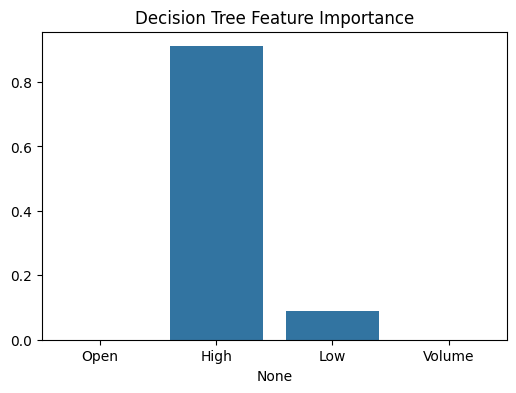

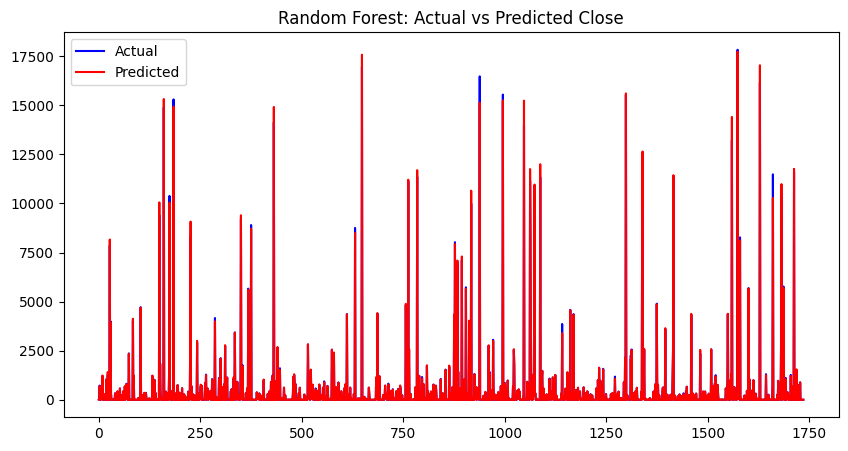

c:\Users\Legion\Desktop\Cripto\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


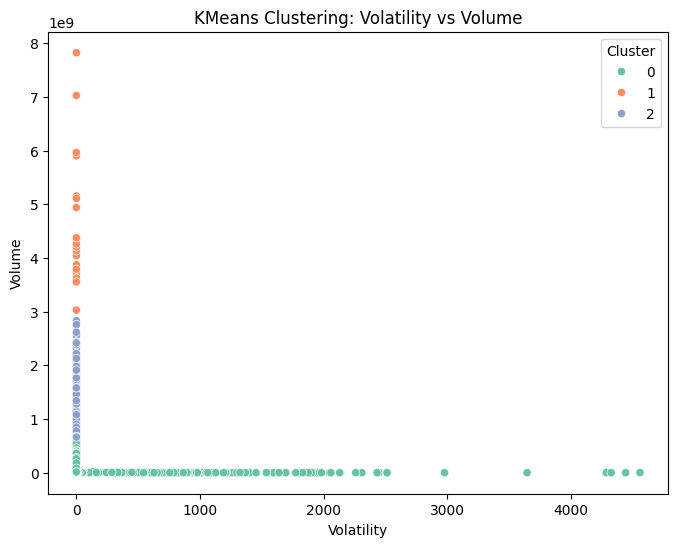

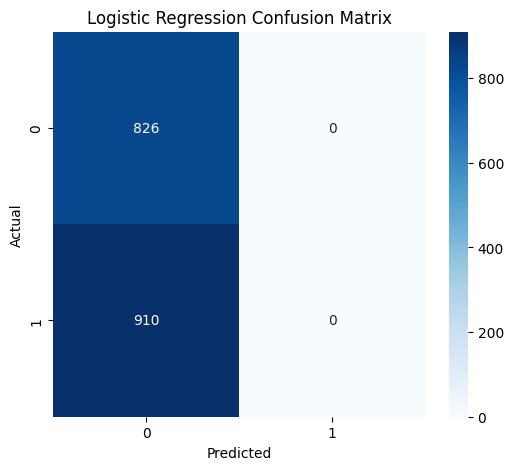

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, confusion_matrix

# Load dataset
df = pd.read_csv("merged_crypto_data.csv")
df['Date'] = pd.to_datetime(df['Date'])

# Features and target
X = df[['Open','High','Low','Volume']]
y = df['Close']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 1. Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel("Actual Close")
plt.ylabel("Predicted Close")
plt.title("Linear Regression: Actual vs Predicted Close")
plt.show()

# --- 2. Decision Tree Regressor ---
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
importances = dt.feature_importances_

plt.figure(figsize=(6,4))
sns.barplot(x=X.columns, y=importances)
plt.title("Decision Tree Feature Importance")
plt.show()

# --- 3. Random Forest Regressor ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(y_pred_rf, label="Predicted", color="red")
plt.title("Random Forest: Actual vs Predicted Close")
plt.legend()
plt.show()

# --- 4. KMeans Clustering ---
df['Volatility'] = df['High'] - df['Low']
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Volatility','Volume']])

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Volatility", y="Volume", hue="Cluster", palette="Set2")
plt.title("KMeans Clustering: Volatility vs Volume")
plt.show()

# --- 5. Logistic Regression (Classification) ---
# Create target: 1 if next day's Close > today's Close, else 0
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna()

X_cls = df[['Open','High','Low','Volume']]
y_cls = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_cls = logreg.predict(X_test)

cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
